# Primordial abundances vs extra relativistic species ΔNeff

## Physical background

The effective number of neutrino species $N_{\rm eff}$ parametrises the total
radiation energy density at BBN:
$$
\rho_{\rm rad} = \rho_\gamma \left[1 + \frac{7}{8}\left(\frac{4}{11}\right)^{4/3} N_{\rm eff}\right].
$$
The Standard Model prediction is $N_{\rm eff} \approx 3.044$.  Any extra
light, decoupled species (sterile neutrinos, axions, gravitinos, …) adds to
$N_{\rm eff}$ through $\Delta N_{\rm eff} = N_{\rm eff} - 3.044$.

A larger $N_{\rm eff}$ means a faster Hubble rate at BBN, which:
- **raises $Y_P$** (neutrons freeze out earlier, more He-4 is produced)
- **raises D/H** (less time for D to be destroyed)
- has smaller effects on He3 and Li7

## What this notebook does

We scan $\Delta N_{\rm eff}$ from $-2$ to $+2$ and compute the four main
BBN observables at each point, including a 1σ nuclear-rate uncertainty band
from a Monte Carlo over all 12 key reaction rates.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import multiprocessing

from primat.backend import run_mc

**Note on backends.** `run_mc`'s results are recoverable identically from either the C or the pure-Python backend: both return the same `MCResult` shape (`mc['key'].mean`/`.std`/`.values`/`.central`, `mc.quantity_names()`, `mc.samples_array()`). Samples are *statistically* (not bit-for-bit) comparable between backends -- the C backend draws with a pthread/xoshiro256** RNG, the Python backend with joblib/numpy's `default_rng` -- so the same seed will not reproduce identical sample values across backends, only matching means/stds at large `num_mc`. Per-sample TSV export is available via `primat.backend.dump_mc_samples(mc)`.


In [2]:
# ---------------------------------------------------------------------------
# Grid and options
# ---------------------------------------------------------------------------

# ΔNeff grid: from -2 to +2 in steps of 0.2
DNeff_vec = np.arange(-2.0, 2.01, 0.2)
npoints   = len(DNeff_vec)

num_mc  = 100 #100     # MC samples per grid point (use ≥100 for publication quality)
num_cpu = multiprocessing.cpu_count()
MC_SEED = 0      # Fixed seed — same rate draws at every ΔNeff value,
                 # so finite-MC bias is correlated across the grid

# Base options: fixed Omega_b h^2 at Planck value.  DeltaNeff (set per
# grid point below) is part of the n<->p weak-rate fingerprint, so each
# DNeff value automatically (re)computes its own rates -- see
# primat.weak_rates and runfiles/generate_table_CLASS_CAMB.py for the
# save_nTOp=True 'seed run' pattern if this becomes a bottleneck.
base_opts = {
    'Omegabh2':          0.02285,
    'show_progress':     False,  # suppress per-sample "[primat] HT./MT./LT." and "[MC] ..." stderr spam
}

print(f"Grid: {npoints} ΔNeff values from {DNeff_vec[0]} to {DNeff_vec[-1]}")
print(f"MC samples per point: {num_mc}  |  CPUs: {num_cpu}")

Grid: 21 ΔNeff values from -2.0 to 1.9999999999999991
MC samples per point: 100  |  CPUs: 8


In [3]:
# ---------------------------------------------------------------------------
# Compute central values and MC uncertainty at each ΔNeff
# ---------------------------------------------------------------------------
# DeltaNeff is passed directly as a PRIMAT parameter.
# The MC randomises all 12 nuclear rates with the same seed at every point.

quantities = ['YPBBN', 'DoH', 'He3oH', 'Li7oH']

cen = {q: np.zeros(npoints) for q in quantities}
err = {q: np.zeros(npoints) for q in quantities}

for i, dN in enumerate(DNeff_vec):
    print(f"  ΔNeff = {dN:+.1f}  ({i+1}/{npoints})", flush=True)
    opts = {**base_opts, 'DeltaNeff': float(dN)}
    mc = run_mc(num_mc, quantities, params=opts,
                n_jobs=num_cpu, seed=MC_SEED)
    for q in quantities:
        cen[q][i] = mc[q].central
        err[q][i] = mc[q].std

print("Done.")

  ΔNeff = -2.0  (1/21)
  ΔNeff = -1.8  (2/21)
  ΔNeff = -1.6  (3/21)
  ΔNeff = -1.4  (4/21)
  ΔNeff = -1.2  (5/21)
  ΔNeff = -1.0  (6/21)
  ΔNeff = -0.8  (7/21)
  ΔNeff = -0.6  (8/21)
  ΔNeff = -0.4  (9/21)
  ΔNeff = -0.2  (10/21)
  ΔNeff = -0.0  (11/21)
  ΔNeff = +0.2  (12/21)
  ΔNeff = +0.4  (13/21)
  ΔNeff = +0.6  (14/21)
  ΔNeff = +0.8  (15/21)
  ΔNeff = +1.0  (16/21)
  ΔNeff = +1.2  (17/21)
  ΔNeff = +1.4  (18/21)
  ΔNeff = +1.6  (19/21)
  ΔNeff = +1.8  (20/21)
  ΔNeff = +2.0  (21/21)
Done.


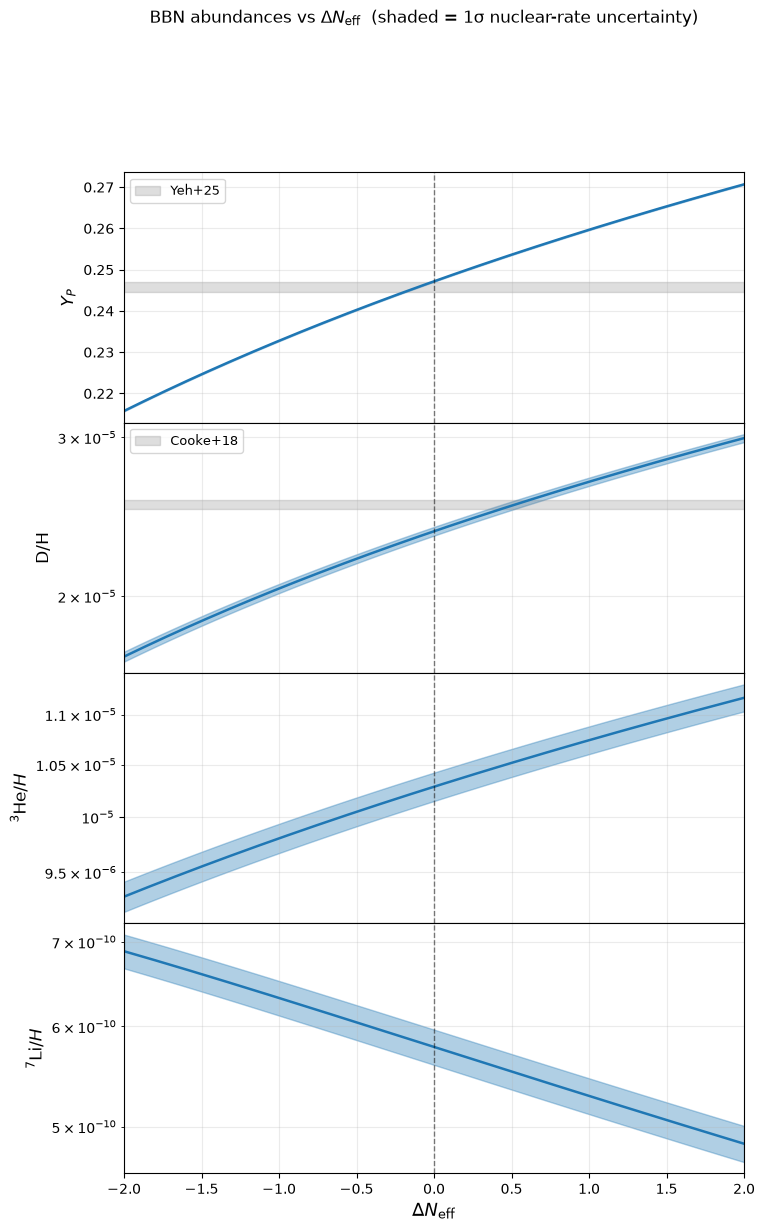

Saved plots/abundances_Nrelat.pdf


In [4]:
# ---------------------------------------------------------------------------
# Plot: abundances vs ΔNeff
# ---------------------------------------------------------------------------
# Shaded band = 1σ nuclear-rate uncertainty.
# Vertical dashed line marks the SM value ΔNeff = 0.
# Observational constraints are shown as grey horizontal bands.

x     = DNeff_vec
xfine = np.linspace(x[0], x[-1], 300)

def smooth(y):
    return interp1d(x, y, kind='cubic')(xfine)

# Observational constraints
YP_obs,  YP_obs_err  = 0.2458,   0.0013      # Yeh et al. 2025
DoH_obs, DoH_obs_err = 2.527e-5, 0.030e-5    # Cooke et al. 2018

panel_info = [
    ('YPBBN', r'$Y_P$',                      False, YP_obs,  YP_obs_err,  'Yeh+25'),
    ('DoH',   r'D/H',                        True,  DoH_obs, DoH_obs_err, 'Cooke+18'),
    ('He3oH', r'$^3{\rm He}/H$',             True,  None,    None,        None),
    ('Li7oH', r'$^7{\rm Li}/H$',             True,  None,    None,        None),
]

c_th  = 'tab:blue'
c_obs = 'tab:gray'

fig, axs = plt.subplots(4, 1, figsize=(8, 13), sharex=True)
fig.subplots_adjust(hspace=0)

for ax, (key, ylabel, log, obs_val, obs_err, obs_label) in zip(axs, panel_info):
    ax.fill_between(xfine,
                    smooth(cen[key] - err[key]),
                    smooth(cen[key] + err[key]),
                    alpha=0.35, color=c_th)
    ax.plot(xfine, smooth(cen[key]), color=c_th, lw=1.8)

    if obs_val is not None:
        ax.axhspan(obs_val - obs_err, obs_val + obs_err,
                   alpha=0.25, color=c_obs, label=obs_label)
        ax.legend(fontsize=9, loc='upper left')

    ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)  # SM: ΔNeff = 0
    ax.set_ylabel(ylabel, fontsize=12)
    if log:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.25)
    ax.tick_params(labelsize=10)

axs[-1].set_xlabel(r'$\Delta N_{\rm eff}$', fontsize=13)
for ax in axs:
    ax.set_xlim(x[0], x[-1])

fig.suptitle(r'BBN abundances vs $\Delta N_{\rm eff}$  '
             r'(shaded = 1σ nuclear-rate uncertainty)', fontsize=12, y=1.005)
plt.savefig('plots/abundances_Nrelat.pdf', bbox_inches='tight')
plt.show()
print("Saved plots/abundances_Nrelat.pdf")

In [5]:
# ---------------------------------------------------------------------------
# Sensitivity: dYP/d(ΔNeff) and d(D/H)/d(ΔNeff)
# ---------------------------------------------------------------------------
# A useful summary is the linear sensitivity of each observable to ΔNeff,
# computed by a simple finite difference around ΔNeff = 0.

# Find the two grid points bracketing ΔNeff = 0
i0 = np.argmin(np.abs(DNeff_vec))          # closest to 0
ip = np.argmin(np.abs(DNeff_vec - 0.2))    # closest to +0.2
im = np.argmin(np.abs(DNeff_vec + 0.2))    # closest to -0.2

dDN = DNeff_vec[ip] - DNeff_vec[im]

print("Linear sensitivities at ΔNeff = 0:")
for q, label in [('YPBBN', 'YP'), ('DoH', 'D/H'), ('He3oH', 'He3/H'), ('Li7oH', 'Li7/H')]:
    deriv = (cen[q][ip] - cen[q][im]) / dDN
    frac  = deriv / cen[q][i0] * 100
    print(f"  d({label})/d(ΔNeff) = {deriv:.4e}   ({frac:+.2f}% per unit ΔNeff)")

Linear sensitivities at ΔNeff = 0:
  d(YP)/d(ΔNeff) = 1.3364e-02   (+5.41% per unit ΔNeff)
  d(D/H)/d(ΔNeff) = 3.1939e-06   (+13.53% per unit ΔNeff)
  d(He3/H)/d(ΔNeff) = 4.6721e-07   (+4.54% per unit ΔNeff)
  d(Li7/H)/d(ΔNeff) = -5.1818e-11   (-8.96% per unit ΔNeff)
